<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/06_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Loading

In [ ]:
import os
import os.path
import time
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.getcwd()

'/content'

In [ ]:
data_path = '/content/drive/My Drive/IDX Exchange/outputs'

In [ ]:
train = pd.read_csv(os.path.join(data_path, 'crmls_sfr_train_X12_2025-05_to_2026-04.csv'))
validation = pd.read_csv(os.path.join(data_path, 'crmls_sfr_validation_2026-05.csv'))
test = pd.read_csv(os.path.join(data_path, 'crmls_sfr_test_2026-06.csv'))

/tmp/ipykernel_1027/2603366486.py:3: DtypeWarning: Columns (74) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(os.path.join(data_path, 'crmls_sfr_test_2026-06.csv'))


In [ ]:
train.shape

(117602, 155)

In [ ]:
train.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail',
       ...
       'PropertyAge_scaled', 'GarageSpaces_scaled', 'ParkingTotal_scaled',
       'Latitude_scaled', 'Longitude_scaled', 'AssociationFee_scaled',
       'Stories_scaled', 'month_sin_scaled', 'month_cos_scaled', 'split'],
      dtype='object', length=155)

## 2. Feature Identification

*   **Intrinsic Property Characteristics**:
    *   `LivingArea`: Square footage
    *   `BedroomsTotal`: Number of bedrooms
    *   `BathroomsTotalDecimal`: Number of bathrooms
    *   `LotSizeSquareFeet`: Lot size
    *   `PropertyAge_scaled`: Age of the property (already scaled)

*   **Location Features**:
    *   `Latitude_scaled`: Latitude (already scaled)
    *   `Longitude_scaled`: Longitude (already scaled)

*   **Temporal Features**:
    *   `month_sin_scaled`: Sine component for sale month (already scaled, captures seasonality)
    *   `month_cos_scaled`: Cosine component for sale month (already scaled, captures seasonality)

*   **Categorical Features (for Encoding)**:
    *   `ViewYN`: Presence of a view (Yes/No)
    *   `WaterfrontYN`: Presence of waterfront (Yes/No)
    *   `BasementYN`: Presence of a basement (Yes/No)
    *   `PoolPrivateYN`: Presence of a private pool (Yes/No)
    ......

In [ ]:
# Numerical fields that are relevant for pricing or data-quality review.
# ClosePrice is included for summary checks but excluded from feature scaling later.
KEY_NUMERIC_COLS = [
    "ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "PropertyAge", "GarageSpaces", "ParkingTotal",
    "Latitude", "Longitude", "AssociationFee", "FireplacesTotal", "Stories",
    "zip_median_price_per_sqft", # New engineered feature
    "month_sin", "month_cos" # Cyclical month features
]

# Binary listing attributes. These are amenity-like fields where values should become 0/1.
BINARY_COLS = [
    "ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN", "latfilled", "lonfilled",
]

# Low-cardinality categorical fields can be one-hot encoded without creating too many columns.
LOW_CARDINALITY_CATEGORICAL_COLS = [
    "Levels", "AssociationFeeFrequency", "StateOrProvince",
]

# Higher-cardinality geographic fields are frequency encoded later.
# This keeps useful market-location signal without creating hundreds of dummy columns.
FREQUENCY_CATEGORICAL_COLS = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
    "HighSchoolDistrict", "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict",
]

# These fields are identifiers, names, addresses, or agent/office fields.
# They are kept in the audit data but should not be treated as stable model features.
DROP_FROM_MODEL = [
    "ListingKey", "ListingKeyNumeric", "ListingId", "UnparsedAddress", "ListAgentEmail",
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "ListOfficeName", "BuyerOfficeName", "CoListOfficeName",
    "BuilderName", "SubdivisionName", "StreetNumberNumeric",
    "ListPrice", "OriginalListPrice", # Excluded as requested
    "DaysOnMarket", # Excluded as requested
    "ContractStatusChangeDate", "PurchaseContractDate", # Excluded as closing/settlement fields
    'BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'CloseDate',
    'PropertyType', 'MlsStatus', 'ElementarySchool', 'PropertySubType',
    'BuyerOfficeAOR', 'CoBuyerAgentFirstName', 'ListingContractDate',
    'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions',
    'close_month', 'split']

## 3. Feature Engineering

### (1) Handling Categorical Features

To prepare the data for the linear regression model, we will encode the categorical features.
Low-cardinality categorical features will be one-hot encoded, and higher-cardinality categorical features will be frequency encoded.

In [ ]:
# One-hot encode low-cardinality categorical features
print(f"Applying One-Hot Encoding to: {LOW_CARDINALITY_CATEGORICAL_COLS}")

for col in LOW_CARDINALITY_CATEGORICAL_COLS:
    # Get all unique categories from the training set for the current column
    # Ensure 'category' dtype to handle potential missing categories in other sets gracefully
    all_categories = train[col].astype('category').cat.categories

    # Convert columns to CategoricalDtype with all known categories
    train_cat = train[col].astype(pd.CategoricalDtype(categories=all_categories))
    val_cat = validation[col].astype(pd.CategoricalDtype(categories=all_categories))
    test_cat = test[col].astype(pd.CategoricalDtype(categories=all_categories))

    # Apply one-hot encoding
    train_encoded = pd.get_dummies(train_cat, prefix=f'{col}_oh', drop_first=True)
    val_encoded = pd.get_dummies(val_cat, prefix=f'{col}_oh', drop_first=True)
    test_encoded = pd.get_dummies(test_cat, prefix=f'{col}_oh', drop_first=True)

    # Concatenate the new dummy variables with the existing dataframes and drop original column
    train = pd.concat([train.drop(columns=[col]), train_encoded], axis=1)
    validation = pd.concat([validation.drop(columns=[col]), val_encoded], axis=1)
    test = pd.concat([test.drop(columns=[col]), test_encoded], axis=1)

print("One-Hot Encoding complete.")


Applying One-Hot Encoding to: ['Levels', 'AssociationFeeFrequency', 'StateOrProvince']
One-Hot Encoding complete.


In [ ]:
# Frequency encode high-cardinality categorical features
print(f"Applying Frequency Encoding to: {FREQUENCY_CATEGORICAL_COLS}")

for col in FREQUENCY_CATEGORICAL_COLS:
    # Calculate frequencies from the training data
    freq_map = train[col].value_counts(normalize=True).to_dict()

    # Apply frequency encoding to all datasets
    # Fillna(0) for categories in validation/test that are not present in train
    train[f'{col}_freq'] = train[col].map(freq_map).fillna(0)
    validation[f'{col}_freq'] = validation[col].map(freq_map).fillna(0)
    test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)

    # Drop the original categorical column
    train = train.drop(columns=[col])
    validation = validation.drop(columns=[col])
    test = test.drop(columns=[col])

print("Frequency Encoding complete.")

# Display the shapes of the dataframes after encoding to confirm changes
print(f"\nTrain shape after encoding: {train.shape}")
print(f"Validation shape after encoding: {validation.shape}")
print(f"Test shape after encoding: {test.shape}")


Applying Frequency Encoding to: ['City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict']
Frequency Encoding complete.

Train shape after encoding: (117602, 173)
Validation shape after encoding: (11873, 173)
Test shape after encoding: (12685, 173)


###(2) Bed/Bath Ratio

In [ ]:
for df in [train, validation, test]:
    # Replace 0 in 'BathroomsTotalInteger' with 1 to avoid division by zero.
    # This assumes that if bathrooms are 0, it's better to treat it as having at least 1 for ratio calculation if there are bedrooms.
    # If 'BedroomsTotal' is also 0, the ratio will be 0.
    df['BathroomsTotalInteger_adjusted'] = df['BathroomsTotalInteger'].replace(0, 1)
    df['BedBathRatio'] = df['BedroomsTotal'] / df['BathroomsTotalInteger_adjusted']
    # Drop the temporary adjusted column
    df.drop(columns=['BathroomsTotalInteger_adjusted'], inplace=True)

print("Bed/Bath Ratio feature engineered for train, validation, and test datasets.")

# Display a sample of the new feature
print("\nTrain DataFrame sample with 'BedBathRatio':")
print(train[['BedroomsTotal', 'BathroomsTotalInteger', 'BedBathRatio']].head())

print("\nValidation DataFrame sample with 'BedBathRatio':")
print(validation[['BedroomsTotal', 'BathroomsTotalInteger', 'BedBathRatio']].head())

print("\nTest DataFrame sample with 'BedBathRatio':")
print(test[['BedroomsTotal', 'BathroomsTotalInteger', 'BedBathRatio']].head())

Bed/Bath Ratio feature engineered for train, validation, and test datasets.

Train DataFrame sample with 'BedBathRatio':
   BedroomsTotal  BathroomsTotalInteger  BedBathRatio
0            2.0                    2.0      1.000000
1            3.0                    2.0      1.500000
2            5.0                    6.0      0.833333
3            4.0                    3.0      1.333333
4            2.0                    2.0      1.000000

Validation DataFrame sample with 'BedBathRatio':
   BedroomsTotal  BathroomsTotalInteger  BedBathRatio
0            2.0                    1.0           2.0
1            2.0                    1.0           2.0
2            2.0                    2.0           1.0
3            3.0                    2.0           1.5
4            3.0                    1.0           3.0

Test DataFrame sample with 'BedBathRatio':
   BedroomsTotal  BathroomsTotalInteger  BedBathRatio
0            5.0                    3.0      1.666667
1            2.0             

### (3) Property Age

In [ ]:
CURRENT_YEAR = 2026

for df in [train, validation, test]:
    # Calculate PropertyAge
    df['PropertyAge'] = CURRENT_YEAR - df['YearBuilt']
    # Handle cases where YearBuilt might be in the future or invalid, setting age to 0 for new properties
    df['PropertyAge'] = df['PropertyAge'].apply(lambda x: max(x, 0))

print("PropertyAge feature engineered for train, validation, and test datasets.")

# Display a sample of the new feature
print("\nTrain DataFrame sample with 'PropertyAge' and 'YearBuilt':")
print(train[['YearBuilt', 'PropertyAge']].head())

print("\nValidation DataFrame sample with 'PropertyAge' and 'YearBuilt':")
print(validation[['YearBuilt', 'PropertyAge']].head())

print("\nTest DataFrame sample with 'PropertyAge' and 'YearBuilt':")
print(test[['YearBuilt', 'PropertyAge']].head())

PropertyAge feature engineered for train, validation, and test datasets.

Train DataFrame sample with 'PropertyAge' and 'YearBuilt':
   YearBuilt  PropertyAge
0     1981.0         45.0
1     1972.0         54.0
2     2007.0         19.0
3     1976.0         50.0
4     1961.0         65.0

Validation DataFrame sample with 'PropertyAge' and 'YearBuilt':
   YearBuilt  PropertyAge
0     1946.0         80.0
1     1926.0        100.0
2     1959.0         67.0
3     1983.0         43.0
4     1955.0         71.0

Test DataFrame sample with 'PropertyAge' and 'YearBuilt':
   YearBuilt  PropertyAge
0     2017.0          9.0
1     1978.0         48.0
2     1929.0         97.0
3     1988.0         38.0
4     1976.0         50.0


### (4) Add Total Amenities Count

Create a new feature 'AmenitiesCount' by summing up relevant binary amenity columns (e.g., 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN') for all datasets. This feature could provide a composite score of desirable property features.


In [ ]:
BINARY_COLS = [
    "ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN"
]

amenity_cols = [col for col in BINARY_COLS if col in train.columns] # Ensure columns exist

for df_name, df in zip(['train', 'validation', 'test'], [train, validation, test]):
    # Ensure amenity columns are numeric (0 or 1)
    for col in amenity_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    # Calculate AmenitiesCount by summing the specified binary amenity columns
    df['AmenitiesCount'] = df[amenity_cols].sum(axis=1)

    print(f"\n{df_name.capitalize()} DataFrame sample with 'AmenitiesCount' and amenity columns:")
    print(df[amenity_cols + ['AmenitiesCount']].head())

print("AmenitiesCount feature engineered for train, validation, and test datasets.")


Train DataFrame sample with 'AmenitiesCount' and amenity columns:
   ViewYN  WaterfrontYN  BasementYN  PoolPrivateYN  AttachedGarageYN  \
0       0             0           0              0                 1   
1       0             0           0              0                 1   
2       1             0           0              1                 1   
3       1             0           0              0                 0   
4       1             0           0              0                 1   

   FireplaceYN  NewConstructionYN  AmenitiesCount  
0            1                  0               2  
1            1                  0               2  
2            1                  0               4  
3            0                  0               1  
4            0                  0               2  

Validation DataFrame sample with 'AmenitiesCount' and amenity columns:
   ViewYN  WaterfrontYN  BasementYN  PoolPrivateYN  AttachedGarageYN  \
0       0             0           0         

### (5) More detailed geographic layer using school districts

In [ ]:
!pip install geopandas

print("GeoPandas installed successfully.")

GeoPandas installed successfully.


In [ ]:
import geopandas as gpd

# Load the 'DistrictAreas.geojson' file
school_districts = gpd.read_file('/content/drive/My Drive/IDX Exchange/DistrictAreas.geojson')

# Filter to include only 'Unified' school districts
school_districts = school_districts[school_districts['DistrictType'] == 'Unified']

print("Filtered Unified School Districts GeoDataFrame:")
print(school_districts.head())
print(f"Shape of filtered school_districts: {school_districts.shape}")

Filtered Unified School Districts GeoDataFrame:
   OBJECTID     Year    FedID   CDCode         CDSCode CountyName  \
0         1  2025-26  0601770  0161119  01611190000000    Alameda   
1         2  2025-26  0601860  0161127  01611270000000    Alameda   
2         3  2025-26  0604740  0161143  01611430000000    Alameda   
3         4  2025-26  0607800  0161150  01611500000000    Alameda   
4         5  2025-26  0612630  0161168  01611680000000    Alameda   

            DistrictName DistrictType GradeLow GradeHigh  ... MIGcount MIGpct  \
0        Alameda Unified      Unified       PK        12  ...        0    0.0   
1    Albany City Unified      Unified       PK        12  ...        0    0.0   
2       Berkeley Unified      Unified       PK        12  ...        0    0.0   
3  Castro Valley Unified      Unified       PK        12  ...        2    0.0   
4          Emery Unified      Unified       PK        12  ...        0    0.0   

  SWDcount SWDpct  SEDcount  SEDpct  DistrctAreaSq

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# Define the CRS (Coordinate Reference System) to use.
# WGS84 (EPSG:4326) is a common geographic CRS for latitude and longitude.
# We will transform it to the school_districts CRS for spatial join if they differ.
CRS = "EPSG:4326"

# Function to create a GeoDataFrame from a DataFrame
def create_property_geodf(df, crs=CRS):
    # Drop rows with NaN in Latitude or Longitude to avoid errors during Point creation
    df_clean = df.dropna(subset=['Latitude', 'Longitude']).copy()
    geometry = [Point(xy) for xy in zip(df_clean['Longitude'], df_clean['Latitude'])]
    return gpd.GeoDataFrame(df_clean, geometry=geometry, crs=crs)

# Create GeoDataFrames for train, validation, and test sets
train_gdf = create_property_geodf(train)
validation_gdf = create_property_geodf(validation)
test_gdf = create_property_geodf(test)

print("Train GeoDataFrame head:")
display(train_gdf.head())
print(f"Shape of train_gdf: {train_gdf.shape}")

print("\nValidation GeoDataFrame head:")
display(validation_gdf.head())
print(f"Shape of validation_gdf: {validation_gdf.shape}")

print("\nTest GeoDataFrame head:")
display(test_gdf.head())
print(f"Shape of test_gdf: {test_gdf.shape}")

Train GeoDataFrame head:


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,City_freq,PostalCode_freq,CountyOrParish_freq,MLSAreaMajor_freq,HighSchoolDistrict_freq,ElementarySchoolDistrict_freq,MiddleOrJuniorSchoolDistrict_freq,BedBathRatio,AmenitiesCount,geometry
0,ContraCosta,ContraCosta,Laminate,0,0,0,0,650000.0,1114213912,renee@blvdeastbay.com,...,0.002372,0.000901,0.016990,0.149309,0.270956,1.0,1.0,1.000000,2,POINT (-120.69502 35.26309)
1,PacificWest,PacificWest,"Carpet,Laminate,Tile",0,0,0,0,720000.0,1112928701,carinlundahl@firstteam.com,...,0.001973,0.001973,0.249894,0.001964,0.002976,1.0,1.0,1.500000,2,POINT (-117.94687 33.99244)
2,PacificSouthwest,PacificSouthwest,NaN,1,0,0,1,2125000.0,1112887687,jorge@ahuagerealty.com,...,0.006241,0.000502,0.111758,0.000502,0.003937,1.0,1.0,0.833333,4,POINT (-116.94296 32.66428)
3,SanDiego,SanDiego,NaN,1,0,0,0,3495000.0,1112709457,tim@timvandamm.com,...,0.000638,0.000646,0.111758,0.000646,0.270956,1.0,1.0,1.333333,1,POINT (-117.24976 32.93701)
4,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,1,0,0,0,1600000.0,1112518797,ScottG@TheAgencyRE.com,...,0.001463,0.001088,0.249894,0.000893,0.270956,1.0,1.0,1.000000,2,POINT (-118.43493 34.10991)


Shape of train_gdf: (117602, 176)

Validation GeoDataFrame head:


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,City_freq,PostalCode_freq,CountyOrParish_freq,MLSAreaMajor_freq,HighSchoolDistrict_freq,ElementarySchoolDistrict_freq,MiddleOrJuniorSchoolDistrict_freq,BedBathRatio,AmenitiesCount,geometry
0,Southland,OrangeCounty,NaN,0,0,0,1,1070000.0,1170383150,alan@lrsrm.com,...,0.002296,0.001301,0.249894,0.002457,0.059786,1.0,1.0,2.0,1,POINT (-118.52022 34.24423)
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Laminate,0,0,0,0,730000.0,1159931881,matthew@matthewhoult.com,...,0.041649,0.001871,0.249894,0.001522,0.270956,1.0,1.0,2.0,0,POINT (-118.311 33.96754)
2,SouthBay,SouthBay,"Tile,Wood",1,0,0,0,1300000.0,1159541083,kimberlydoner@gmail.com,...,0.005034,0.001258,0.249894,0.000332,0.004651,1.0,1.0,1.0,3,POINT (-118.33844 33.83222)
3,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,0,0,0,0,1800000.0,1159508997,courtneyp@serhant.com,...,0.002636,0.002636,0.111758,0.002619,0.270956,1.0,1.0,1.5,2,POINT (-117.24912 33.05533)
4,SouthBay,SouthBay,NaN,0,0,0,0,1390000.0,1159278664,kristi@kristiseth.com,...,0.005034,0.001258,0.249894,0.000553,0.004651,1.0,1.0,3.0,0,POINT (-118.3667 33.84988)


Shape of validation_gdf: (11873, 176)

Test GeoDataFrame head:


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,City_freq,PostalCode_freq,CountyOrParish_freq,MLSAreaMajor_freq,HighSchoolDistrict_freq,ElementarySchoolDistrict_freq,MiddleOrJuniorSchoolDistrict_freq,BedBathRatio,AmenitiesCount,geometry
0,BayEast,BayEast,"Carpet,Tile",0,0,0,0,382200.0,1175301961,pamela@pdcrealestate.com,...,0.000145,0.000136,0.001735,0.149309,0.270956,1.0,1.0,1.666667,1,POINT (-121.26506 37.39567)
1,Mlslistings,Mlslistings,NaN,0,0,0,0,NaN,1173065141,realtorshannon@gmail.com,...,0.002228,0.001122,0.006590,0.085211,0.059455,1.0,1.0,1.000000,2,POINT (-122.0497 36.96234)
2,Mlslistings,Mlslistings,"Tile,Wood",0,0,0,0,NaN,1173057254,juliette@kuldagroup.com,...,0.000689,0.000689,0.014498,0.085211,0.059455,1.0,1.0,2.000000,1,POINT (-122.29927 37.5144)
3,SanDiego,PacificSouthwest,NaN,1,0,0,0,1245000.0,1172691496,gponethree@hotmail.com,...,0.000604,0.000595,0.111758,0.000595,0.003937,1.0,1.0,1.500000,3,POINT (-117.13073 32.58006)
4,NaN,TuolumneCountyAssociationOfRealtors,"Carpet,Laminate",0,0,0,0,389000.0,1172314884,shelbyfrenchsells@gmail.com,...,0.000000,0.000000,0.000238,0.149309,0.270956,1.0,1.0,1.000000,2,POINT (-120.57231 38.19421)


Shape of test_gdf: (12685, 176)


In [ ]:
print(f"CRS of school_districts: {school_districts.crs}")
print(f"CRS of train_gdf: {train_gdf.crs}")

# Ensure CRS consistency before spatial join
# If they are not the same, transform the property GDFs to match the school_districts CRS
if train_gdf.crs != school_districts.crs:
    print(f"Transforming property GDFs CRS from {train_gdf.crs} to {school_districts.crs} for spatial join.")
    train_gdf = train_gdf.to_crs(school_districts.crs)
    validation_gdf = validation_gdf.to_crs(school_districts.crs)
    test_gdf = test_gdf.to_crs(school_districts.crs)

print(f"CRS of train_gdf after transformation: {train_gdf.crs}")


# Perform spatial join for each dataset
# Using 'left' join to keep all properties and assign NaN if no district is found
print("Performing spatial join for train set...")
train_joined = gpd.sjoin(train_gdf, school_districts[['DistrictName', 'geometry']], how='left', predicate='within')
print("Performing spatial join for validation set...")
validation_joined = gpd.sjoin(validation_gdf, school_districts[['DistrictName', 'geometry']], how='left', predicate='within')
print("Performing spatial join for test set...")
test_joined = gpd.sjoin(test_gdf, school_districts[['DistrictName', 'geometry']], how='left', predicate='within')

# Add DistrictName to the original DataFrames
# Merge based on the original index to ensure correct alignment
train = train.merge(train_joined[['DistrictName']], left_index=True, right_index=True, how='left')
validation = validation.merge(validation_joined[['DistrictName']], left_index=True, right_index=True, how='left')
test = test.merge(test_joined[['DistrictName']], left_index=True, right_index=True, how='left')

# Handle properties that did not fall into any school district
# Fill NaN DistrictName with 'Unknown District'
train['DistrictName'] = train['DistrictName'].fillna('Unknown District')
validation['DistrictName'] = validation['DistrictName'].fillna('Unknown District')
test['DistrictName'] = test['DistrictName'].fillna('Unknown District')

print("Spatial join complete. 'DistrictName' added to original DataFrames.")

print("\nTrain DataFrame head with 'DistrictName':")
display(train[['Latitude', 'Longitude', 'DistrictName']].head())
print(f"Number of unique districts in train: {train['DistrictName'].nunique()}")

print("\nValidation DataFrame head with 'DistrictName':")
display(validation[['Latitude', 'Longitude', 'DistrictName']].head())
print(f"Number of unique districts in validation: {validation['DistrictName'].nunique()}")

print("\nTest DataFrame head with 'DistrictName':")
display(test[['Latitude', 'Longitude', 'DistrictName']].head())
print(f"Number of unique districts in test: {test['DistrictName'].nunique()}")

CRS of school_districts: EPSG:3857
CRS of train_gdf: EPSG:4326
Transforming property GDFs CRS from EPSG:4326 to EPSG:3857 for spatial join.
CRS of train_gdf after transformation: EPSG:3857
Performing spatial join for train set...
Performing spatial join for validation set...
Performing spatial join for test set...
Spatial join complete. 'DistrictName' added to original DataFrames.

Train DataFrame head with 'DistrictName':


,Latitude,Longitude,DistrictName
0,35.263088,-120.695025,San Luis Coastal Unified
1,33.992438,-117.946873,Hacienda la Puente Unified
2,32.664281,-116.942963,Unknown District
3,32.937005,-117.249756,Unknown District
4,34.109909,-118.434926,Los Angeles Unified


Number of unique districts in train: 313

Validation DataFrame head with 'DistrictName':


,Latitude,Longitude,DistrictName
0,34.244231,-118.520225,Los Angeles Unified
1,33.967544,-118.310996,Los Angeles Unified
2,33.832220,-118.338439,Torrance Unified
3,33.055332,-117.249119,Unknown District
4,33.849877,-118.366702,Torrance Unified


Number of unique districts in validation: 262

Test DataFrame head with 'DistrictName':


,Latitude,Longitude,DistrictName
0,37.395670,-121.265062,Newman-Crows Landing Unified
1,36.962341,-122.049700,Unknown District
2,37.514396,-122.299274,Unknown District
3,32.580060,-117.130734,Unknown District
4,38.194211,-120.572306,Calaveras Unified


Number of unique districts in test: 260


In [ ]:
# Add 'DistrictName' to the list of high-cardinality categorical features for frequency encoding
if 'DistrictName' not in FREQUENCY_CATEGORICAL_COLS:
    FREQUENCY_CATEGORICAL_COLS.append('DistrictName')

print(f"Updated FREQUENCY_CATEGORICAL_COLS: {FREQUENCY_CATEGORICAL_COLS}")

Updated FREQUENCY_CATEGORICAL_COLS: ['City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict', 'DistrictName']


In [ ]:
# Frequency encode high-cardinality categorical features
print(f"Applying Frequency Encoding to: {FREQUENCY_CATEGORICAL_COLS}")

# Ensure we are working with fresh copies to avoid issues with already dropped columns
# Reloading data is not feasible as previous steps modified 'train', 'validation', 'test'
# So, we need to handle columns that might have been dropped in previous runs carefully

# Make a copy of the current dataframes to work with for re-encoding
train_re_encode = train.copy()
validation_re_encode = validation.copy()
test_re_encode = test.copy()

for col in FREQUENCY_CATEGORICAL_COLS:
    if col in train_re_encode.columns: # Check if the column exists before processing
        # Calculate frequencies from the training data
        freq_map = train_re_encode[col].value_counts(normalize=True).to_dict()

        # Apply frequency encoding to all datasets
        # Fillna(0) for categories in validation/test that are not present in train
        train_re_encode[f'{col}_freq'] = train_re_encode[col].map(freq_map).fillna(0)
        validation_re_encode[f'{col}_freq'] = validation_re_encode[col].map(freq_map).fillna(0)
        test_re_encode[f'{col}_freq'] = test_re_encode[col].map(freq_map).fillna(0)

        # Drop the original categorical column
        train_re_encode = train_re_encode.drop(columns=[col])
        validation_re_encode = validation_re_encode.drop(columns=[col])
        test_re_encode = test_re_encode.drop(columns=[col])
    else:
        print(f"Warning: Column '{col}' not found in dataframes for frequency encoding. Skipping.")

# Update the original dataframes with the re-encoded versions
train = train_re_encode
validation = validation_re_encode
test = test_re_encode

print("Frequency Encoding complete.")

# Display the shapes of the dataframes after encoding to confirm changes
print(f"\nTrain shape after re-encoding: {train.shape}")
print(f"Validation shape after re-encoding: {validation.shape}")
print(f"Test shape after re-encoding: {test.shape}")

Applying Frequency Encoding to: ['City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict', 'DistrictName']
Frequency Encoding complete.

Train shape after re-encoding: (117602, 176)
Validation shape after re-encoding: (11873, 176)
Test shape after re-encoding: (12685, 176)


## 4. Re-define Feature Set and Handle NaNs


In [ ]:
DROP_FROM_MODEL.append('YearBuilt') # Add YearBuilt to DROP_FROM_MODEL as we are using PropertyAge

# Define target and update features to include new engineered features
TARGET_COL = 'ClosePrice'

# Start with existing feature columns, excluding 'ClosePrice' and DROP_FROM_MODEL
feature_columns = [
    c for c in train.columns
    if c not in DROP_FROM_MODEL + [TARGET_COL]
]

# Remove 'PropertyAge_scaled' if it exists and we're replacing it with our new 'PropertyAge'
if 'PropertyAge_scaled' in feature_columns:
    feature_columns.remove('PropertyAge_scaled')

# Add the newly engineered features
new_engineered_features = ['BedBathRatio', 'PropertyAge', 'AmenitiesCount']
for feature in new_engineered_features:
    if feature not in feature_columns:
        feature_columns.append(feature)

# Ensure the frequency encoded DistrictName is included
if 'DistrictName_freq' not in feature_columns:
    feature_columns.append('DistrictName_freq')

X_train = train[feature_columns]
y_train = train[TARGET_COL]

X_val = validation[feature_columns]
y_val = validation[TARGET_COL]

X_test = test[feature_columns]
y_test = test[TARGET_COL]

print(f"Number of features: {len(feature_columns)}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Number of features: 133
X_train shape: (117602, 133)
y_train shape: (117602,)
X_val shape: (11873, 133)
y_val shape: (11873,)
X_test shape: (12685, 133)
y_test shape: (12685,)


### Handling Missing Values (NaNs)

As identified, the datasets still contain missing values, which prevent the linear regression model from training. We will now handle these NaNs by:
1. Dropping columns that have a very high percentage of missing values (e.g., more than 90%).
2. Imputing the remaining numerical NaN values with the mean of their respective columns from the training set, to avoid data leakage.

In [ ]:
# Calculate the percentage of NaN values for each column in X_train
nan_percentage = X_train.isnull().sum() / len(X_train) * 100
print("Percentage of NaN values in X_train for each column:\n", nan_percentage[nan_percentage > 0])

# Identify columns with more than 90% NaN values to drop
columns_to_drop_high_nan = nan_percentage[nan_percentage > 90].index.tolist()

print(f"\nColumns to drop due to high NaN percentage (>90%): {columns_to_drop_high_nan}")

# Drop these columns from X_train, X_val, and X_test
X_train = X_train.drop(columns=columns_to_drop_high_nan)
X_val = X_val.drop(columns=columns_to_drop_high_nan)
X_test = X_test.drop(columns=columns_to_drop_high_nan)

print(f"\nShapes after dropping high NaN columns: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")

Percentage of NaN values in X_train for each column:
 FireplacesTotal           100.000000
AboveGradeFinishedArea    100.000000
TaxAnnualAmount           100.000000
LotSizeAcres                1.763575
TaxYear                   100.000000
BuildingAreaTotal          93.527321
BelowGradeFinishedArea     99.312937
BusinessType              100.000000
CoveredSpaces             100.000000
LotSizeArea                 1.761024
MainLevelBedrooms          39.552048
dtype: float64

Columns to drop due to high NaN percentage (>90%): ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'TaxYear', 'BuildingAreaTotal', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces']

Shapes after dropping high NaN columns: X_train=(117602, 125), X_val=(11873, 125), X_test=(12685, 125)


In [ ]:
# Identify remaining columns with NaN values
remaining_nan_cols = X_train.isnull().sum()[X_train.isnull().sum() > 0].index.tolist()
print(f"\nRemaining columns with NaNs to impute: {remaining_nan_cols}")

# Impute remaining NaN values with the mean from the training set
for col in remaining_nan_cols:
    mean_val = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_val)
    X_val[col] = X_val[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

print("\nNaN imputation complete. Verifying no NaNs remain:")
print("NaNs in X_train after imputation:", X_train.isnull().sum().sum())
print("NaNs in X_val after imputation:", X_val.isnull().sum().sum())
print("NaNs in X_test after imputation:", X_test.isnull().sum().sum())


Remaining columns with NaNs to impute: ['LotSizeAcres', 'LotSizeArea', 'MainLevelBedrooms']

NaN imputation complete. Verifying no NaNs remain:
NaNs in X_train after imputation: 0
NaNs in X_val after imputation: 0
NaNs in X_test after imputation: 0


## 5. Linear Regression Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model_fit = linear_model.fit(X_train, y_train)

print("Linear Regression model re-trained successfully with imputed data.")

Linear Regression model re-trained successfully with imputed data.


### Enhanced Model Evaluation Metrics

To provide a more comprehensive evaluation of the linear regression model's performance, we will calculate and report additional metrics, specifically the Mean Absolute Percentage Error (MAPE) and Median Absolute Percentage Error (MdAPE), alongside the previously calculated R-squared (R²) and Mean Absolute Error (MAE).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Generate predictions for validation and test sets
y_val_pred = linear_model_fit.predict(X_val)
y_test_pred = linear_model_fit.predict(X_test)

# Calculate additional metrics for validation set
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100
md_ape_val = median_absolute_percentage_error(y_val, y_val_pred)

# Calculate additional metrics for test set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100
md_ape_test = median_absolute_percentage_error(y_test, y_test_pred)

# Report all metrics together
print("\n--- Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val:.4f}")
print(f"  MAE: {mae_val:,.2f}")
print(f"  MAPE: {mape_val:,.2f}%")
print(f"  MdAPE: {md_ape_val:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test:.4f}")
print(f"  MAE: {mae_test:,.2f}")
print(f"  MAPE: {mape_test:,.2f}%")
print(f"  MdAPE: {md_ape_test:,.2f}%")


--- Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.6359
  MAE: 393,599.08
  MAPE: 39.34%
  MdAPE: 26.36%

Test Set Metrics:
  R-squared: -1.3633
  MAE: 576,815.78
  MAPE: 62.89%
  MdAPE: 27.16%


## 6. Decision Tree Regressor Model Training and Evaluation

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42) # Using a random_state for reproducibility
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


In [ ]:
# Make predictions on the validation and test sets
y_val_pred_dt = decision_tree_model.predict(X_val)
y_test_pred_dt = decision_tree_model.predict(X_test)

# Evaluate model performance on validation set
mae_val_dt = mean_absolute_error(y_val, y_val_pred_dt)
mse_val_dt = mean_squared_error(y_val, y_val_pred_dt)
rmse_val_dt = np.sqrt(mse_val_dt)
r2_val_dt = r2_score(y_val, y_val_pred_dt)
mape_val_dt = mean_absolute_percentage_error(y_val, y_val_pred_dt) * 100
md_ape_val_dt = median_absolute_percentage_error(y_val, y_val_pred_dt)

# Evaluate model performance on test set
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)
mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
rmse_test_dt = np.sqrt(mse_test_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)
mape_test_dt = mean_absolute_percentage_error(y_test, y_test_pred_dt) * 100
md_ape_test_dt = median_absolute_percentage_error(y_test, y_test_pred_dt)

print("\n--- Decision Tree Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_dt:.4f}")
print(f"  MAE: {mae_val_dt:,.2f}")
print(f"  MAPE: {mape_val_dt:,.2f}%")
print(f"  MdAPE: {md_ape_val_dt:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_dt:.4f}")
print(f"  MAE: {mae_test_dt:,.2f}")
print(f"  MAPE: {mape_test_dt:,.2f}%")
print(f"  MdAPE: {md_ape_test_dt:,.2f}%")


--- Decision Tree Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.7282
  MAE: 251,423.87
  MAPE: 18.54%
  MdAPE: 11.54%

Test Set Metrics:
  R-squared: 0.7178
  MAE: 256,101.42
  MAPE: 18.98%
  MdAPE: 11.96%


## 7. Random Forest Regressor Model Training and Evaluation

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Using n_jobs=-1 to utilize all available cores
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [ ]:
# Make predictions on the validation and test sets
y_val_pred_rf = random_forest_model.predict(X_val)
y_test_pred_rf = random_forest_model.predict(X_test)

# Evaluate model performance on validation set
mae_val_rf = mean_absolute_error(y_val, y_val_pred_rf)
mse_val_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_val_rf = np.sqrt(mse_val_rf)
r2_val_rf = r2_score(y_val, y_val_pred_rf)
mape_val_rf = mean_absolute_percentage_error(y_val, y_val_pred_rf) * 100
md_ape_val_rf = median_absolute_percentage_error(y_val, y_val_pred_rf)

# Evaluate model performance on test set
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
mape_test_rf = mean_absolute_percentage_error(y_test, y_test_pred_rf) * 100
md_ape_test_rf = median_absolute_percentage_error(y_test, y_test_pred_rf)

print("\n--- Random Forest Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_rf:.4f}")
print(f"  MAE: {mae_val_rf:,.2f}")
print(f"  MAPE: {mape_val_rf:,.2f}%")
print(f"  MdAPE: {md_ape_val_rf:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_rf:.4f}")
print(f"  MAE: {mae_test_rf:,.2f}")
print(f"  MAPE: {mape_test_rf:,.2f}%")
print(f"  MdAPE: {md_ape_test_rf:,.2f}%")


--- Random Forest Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.8738
  MAE: 175,574.37
  MAPE: 13.07%
  MdAPE: 8.12%

Test Set Metrics:
  R-squared: 0.8639
  MAE: 179,154.00
  MAPE: 13.55%
  MdAPE: 8.35%


## 8. Gradient Boosting (XGBoost) Model Training and Evaluation

### GridSearchCV for Hyperparameter Optimization

In [ ]:
# Install XGBoost if not already installed
!pip install xgboost

print("XGBoost installed successfully.")

XGBoost installed successfully.


In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

xgb_model.fit(X_train, y_train)

y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Define the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist')

# Define a parameter grid for light hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05]
}

print("Performing GridSearchCV for XGBoost. This may take some time...")

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=3, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best estimator
best_xgb_model = grid_search.best_estimator_

print(f"Best parameters found: {grid_search.best_params_}")
print("XGBoost Regressor model trained successfully with best parameters.")

Performing GridSearchCV for XGBoost. This may take some time...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost Regressor model trained successfully with best parameters.


In [ ]:
# Make predictions on the validation and test sets using the best XGBoost model
y_val_pred_xgb = best_xgb_model.predict(X_val)
y_test_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate model performance on validation set
mae_val_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
mse_val_xgb = mean_squared_error(y_val, y_val_pred_xgb)
rmse_val_xgb = np.sqrt(mse_val_xgb)
r2_val_xgb = r2_score(y_val, y_val_pred_xgb)
mape_val_xgb = mean_absolute_percentage_error(y_val, y_val_pred_xgb) * 100
md_ape_val_xgb = median_absolute_percentage_error(y_val, y_val_pred_xgb)

# Evaluate model performance on test set
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
mse_test_xgb = mean_squared_error(y_test, y_test_pred_xgb)
rmse_test_xgb = np.sqrt(mse_test_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)
mape_test_xgb = mean_absolute_percentage_error(y_test, y_test_pred_xgb) * 100
md_ape_test_xgb = median_absolute_percentage_error(y_test, y_test_pred_xgb)

print("\n--- XGBoost Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_xgb:.4f}")
print(f"  MAE: {mae_val_xgb:,.2f}")
print(f"  MAPE: {mape_val_xgb:,.2f}%")
print(f"  MdAPE: {md_ape_val_xgb:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_xgb:.4f}")
print(f"  MAE: {mae_test_xgb:,.2f}")
print(f"  MAPE: {mape_test_xgb:,.2f}%")
print(f"  MdAPE: {md_ape_test_xgb:,.2f}%")


--- XGBoost Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.8649
  MAE: 205,136.09
  MAPE: 16.82%
  MdAPE: 11.72%

Test Set Metrics:
  R-squared: 0.8597
  MAE: 207,989.84
  MAPE: 17.61%
  MdAPE: 11.88%


### Manual Light Hyperparameter Tuning

In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

xgb_model.fit(X_train, y_train)

y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Evaluate model performance on validation set
mae_val_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
mse_val_xgb = mean_squared_error(y_val, y_val_pred_xgb)
rmse_val_xgb = np.sqrt(mse_val_xgb)
r2_val_xgb = r2_score(y_val, y_val_pred_xgb)
mape_val_xgb = mean_absolute_percentage_error(y_val, y_val_pred_xgb) * 100
md_ape_val_xgb = median_absolute_percentage_error(y_val, y_val_pred_xgb)

# Evaluate model performance on test set
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
mse_test_xgb = mean_squared_error(y_test, y_test_pred_xgb)
rmse_test_xgb = np.sqrt(mse_test_xgb)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)
mape_test_xgb = mean_absolute_percentage_error(y_test, y_test_pred_xgb) * 100
md_ape_test_xgb = median_absolute_percentage_error(y_test, y_test_pred_xgb)

print("\n--- XGBoost Model Performance Metrics ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_xgb:.4f}")
print(f"  MAE: {mae_val_xgb:,.2f}")
print(f"  MAPE: {mape_val_xgb:,.2f}%")
print(f"  MdAPE: {md_ape_val_xgb:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_xgb:.4f}")
print(f"  MAE: {mae_test_xgb:,.2f}")
print(f"  MAPE: {mape_test_xgb:,.2f}%")
print(f"  MdAPE: {md_ape_test_xgb:,.2f}%")


--- XGBoost Model Performance Metrics ---

Validation Set Metrics:
  R-squared: 0.8546
  MAE: 210,197.15
  MAPE: 17.13%
  MdAPE: 11.93%

Test Set Metrics:
  R-squared: 0.8551
  MAE: 209,621.88
  MAPE: 17.52%
  MdAPE: 12.01%


In [ ]:
# light hyperparameter tuning
configs = [
    {"max_depth":3,"learning_rate":0.1,"n_estimators":100},
    {"max_depth":5,"learning_rate":0.1,"n_estimators":100},
    {"max_depth":5,"learning_rate":0.05,"n_estimators":200},
    {"max_depth":7,"learning_rate":0.05,"n_estimators":300},
]

In [ ]:
results = []

for cfg in configs:

    model = XGBRegressor(
        random_state=42,
        max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"],
        n_estimators=cfg["n_estimators"]
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    results.append({
        "Depth":cfg["max_depth"],
        "LR":cfg["learning_rate"],
        "Trees":cfg["n_estimators"],
        "RMSE":np.sqrt(mean_squared_error(y_val,pred)),
        "R2":r2_score(y_val,pred)
    })

pd.DataFrame(results)

,Depth,LR,Trees,RMSE,R2
0,3,0.10,100,482396.083216,0.765915
1,5,0.10,100,403945.242923,0.835861
2,5,0.05,200,401692.471039,0.837687
3,7,0.05,300,347473.903806,0.878546


In [ ]:
best_xgb = XGBRegressor(
    max_depth=7,
    learning_rate=0.05,
    n_estimators=300,
    random_state=42
)

best_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_val_pred = best_xgb.predict(X_val)
y_test_pred = best_xgb.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Evaluate best_xgb (from light tuning) performance on validation set
mae_val_best_xgb_manual = mean_absolute_error(y_val, y_val_pred)
mse_val_best_xgb_manual = mean_squared_error(y_val, y_val_pred)
rmse_val_best_xgb_manual = np.sqrt(mse_val_best_xgb_manual)
r2_val_best_xgb_manual = r2_score(y_val, y_val_pred)
mape_val_best_xgb_manual = mean_absolute_percentage_error(y_val, y_val_pred) * 100
md_ape_val_best_xgb_manual = median_absolute_percentage_error(y_val, y_val_pred)

# Evaluate best_xgb (from light tuning) performance on test set
mae_test_best_xgb_manual = mean_absolute_error(y_test, y_test_pred)
mse_test_best_xgb_manual = mean_squared_error(y_test, y_test_pred)
rmse_test_best_xgb_manual = np.sqrt(mse_test_best_xgb_manual)
r2_test_best_xgb_manual = r2_score(y_test, y_test_pred)
mape_test_best_xgb_manual = mean_absolute_percentage_error(y_test, y_test_pred) * 100
md_ape_test_best_xgb_manual = median_absolute_percentage_error(y_test, y_test_pred)

print("\n--- Best XGBoost Model Performance Metrics (from light tuning) ---")

print("\nValidation Set Metrics:")
print(f"  R-squared: {r2_val_best_xgb_manual:.4f}")
print(f"  MAE: {mae_val_best_xgb_manual:,.2f}")
print(f"  MAPE: {mape_val_best_xgb_manual:,.2f}%")
print(f"  MdAPE: {md_ape_val_best_xgb_manual:,.2f}%")

print("\nTest Set Metrics:")
print(f"  R-squared: {r2_test_best_xgb_manual:.4f}")
print(f"  MAE: {mae_test_best_xgb_manual:,.2f}")
print(f"  MAPE: {mape_test_best_xgb_manual:,.2f}%")
print(f"  MdAPE: {md_ape_test_best_xgb_manual:,.2f}%")


--- Best XGBoost Model Performance Metrics (from light tuning) ---

Validation Set Metrics:
  R-squared: 0.8785
  MAE: 186,709.41
  MAPE: 14.97%
  MdAPE: 10.09%

Test Set Metrics:
  R-squared: 0.8750
  MAE: 187,980.31
  MAPE: 15.45%
  MdAPE: 10.07%


## 9. Model Comparison and Analysis

Now, let's compare the performance of the Linear Regression, Decision Tree, and Random Forest models using the evaluation metrics calculated on both the validation and test sets. We'll summarize the key metrics to facilitate comparison and then discuss the observed strengths and weaknesses of each model.

In [ ]:
model_comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost (Manual Tuning)'],
    'Validation R-squared': [r2_val, r2_val_dt, r2_val_rf, r2_val_best_xgb_manual],
    'Validation MAE': [mae_val, mae_val_dt, mae_val_rf, mae_val_best_xgb_manual],
    'Validation MAPE': [mape_val, mape_val_dt, mape_val_rf, mape_val_best_xgb_manual],
    'Validation MdAPE': [md_ape_val, md_ape_val_dt, md_ape_val_rf, md_ape_val_best_xgb_manual],
    'Test R-squared': [r2_test, r2_test_dt, r2_test_rf, r2_test_best_xgb_manual],
    'Test MAE': [mae_test, mae_test_dt, mae_test_rf, mae_test_best_xgb_manual],
    'Test MAPE': [mape_test, mape_test_dt, mape_test_rf, mape_test_best_xgb_manual],
    'Test MdAPE': [md_ape_test, md_ape_test_dt, md_ape_test_rf, md_ape_test_best_xgb_manual]
}

model_comparison_df = pd.DataFrame(model_comparison_data)

# Format the numerical columns for better readability
for col in model_comparison_df.columns:
    if 'R-squared' in col:
        model_comparison_df[col] = model_comparison_df[col].map('{:.4f}'.format)
    elif 'MAE' in col:
        model_comparison_df[col] = model_comparison_df[col].map('{:,.2f}'.format)
    elif 'MAPE' in col or 'MdAPE' in col:
        model_comparison_df[col] = model_comparison_df[col].map('{:,.2f}%'.format)

display(model_comparison_df)

,Model,Validation R-squared,Validation MAE,Validation MAPE,Validation MdAPE,Test R-squared,Test MAE,Test MAPE,Test MdAPE
0,Linear Regression,0.6359,"393,599.08",39.34%,26.36%,-1.3633,"576,815.78",62.89%,27.16%
1,Decision Tree,0.7282,"251,423.87",18.54%,11.54%,0.7178,"256,101.42",18.98%,11.96%
2,Random Forest,0.8738,"175,574.37",13.07%,8.12%,0.8639,"179,154.00",13.55%,8.35%
3,XGBoost (Manual Tuning),0.8785,"186,709.41",14.97%,10.09%,0.8750,"187,980.31",15.45%,10.07%


#### **Overall Model Comparison**

The comparison of the four regression models shows that ensemble tree-based methods consistently outperformed the simpler models. Linear Regression produced the weakest performance, while Decision Tree significantly improved prediction accuracy. Both Random Forest and XGBoost achieved substantially better results, demonstrating the advantages of ensemble learning for this dataset.



#### **Performance of the Newly Added XGBoost Model**

The XGBoost model achieved a Validation R² of 0.8785 and a Test R² of 0.8750, which are the highest among all four models. This indicates that XGBoost explained the largest proportion of variance in house prices and generalized well from the validation set to the test set.

The Validation and Test R² values are also very close (0.8785 vs. 0.8750), suggesting that the model does not exhibit obvious overfitting after manual hyperparameter tuning.

However, when examining the error-based metrics, the results are more nuanced.



Although XGBoost achieved the highest coefficient of determination (R²), Random Forest produced consistently lower prediction errors, including MAE, MAPE and MdAPE on both the validation and test datasets.

This means that:

* **XGBoost** captured slightly more overall variance in the target variable.
* **Random Forest** generated more accurate individual predictions, with smaller average and percentage errors.

The tuned XGBoost model achieved a test R² of 0.8750, with a MAPE of 15.45% and a MdAPE of 10.07%. The similarity between validation and test performance suggests good generalization and no obvious overfitting. While XGBoost achieved the highest R², Random Forest demonstrated better prediction accuracy based on MAE, MAPE and MdAPE.

## 9. Price-band Performance

To evaluate the model's performance across different price ranges, we analyzed the Mean Absolute Percentage Error (MAPE) and Median Absolute Percentage Error (MdAPE) within specific price bands. This helps in understanding where the model performs well and where it struggles.

In [ ]:
evaluation_df = pd.DataFrame({
    "ActualPrice": np.array(y_test),
    "PredictedPrice": np.array(y_test_pred)
})

evaluation_df.head()

,ActualPrice,PredictedPrice
0,382200.0,613667.375
1,1225000.0,1383559.000
2,1575000.0,2000055.250
3,1245000.0,991617.875
4,389000.0,445253.375


In [ ]:
evaluation_df["AbsoluteError"] = np.abs(
    evaluation_df["ActualPrice"] -
    evaluation_df["PredictedPrice"]
)

evaluation_df["AbsolutePercentageError"] = (
    evaluation_df["AbsoluteError"] /
    evaluation_df["ActualPrice"]
) * 100

evaluation_df.head()

,ActualPrice,PredictedPrice,AbsoluteError,AbsolutePercentageError
0,382200.0,613667.375,231467.375,60.561846
1,1225000.0,1383559.000,158559.000,12.943592
2,1575000.0,2000055.250,425055.250,26.987635
3,1245000.0,991617.875,253382.125,20.351978
4,389000.0,445253.375,56253.375,14.461022


In [ ]:
bins = [
    0,
    500_000,
    750_000,
    1_000_000,
    1_500_000,
    2_000_000,
    np.inf
]

labels = [
    "Under $500K",
    "$500K-$750K",
    "$750K-$1M",
    "$1M-$1.5M",
    "$1.5M-$2M",
    "$2M+"
]

evaluation_df["PriceBand"] = pd.cut(
    evaluation_df["ActualPrice"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
evaluation_df["PriceBand"].value_counts().sort_index()

,count
PriceBand,
Under $500K,1742
$500K-$750K,2744
$750K-$1M,2579
$1M-$1.5M,2559
$1.5M-$2M,1381
$2M+,1680


In [ ]:
price_band_summary = (
    evaluation_df
    .groupby("PriceBand", observed=True)
    .agg(
        Count=("ActualPrice", "size"),
        MAE=("AbsoluteError", "mean"),
        MAPE=("AbsolutePercentageError", "mean"),
        MdAPE=("AbsolutePercentageError", "median")
    )
    .reset_index()
)

price_band_summary

,PriceBand,Count,MAE,MAPE,MdAPE
0,Under $500K,1742,85410.853137,23.460089,12.981642
1,$500K-$750K,2744,87796.506981,14.051897,8.417101
2,$750K-$1M,2579,115203.573224,13.109916,8.524180
3,$1M-$1.5M,2559,176174.119016,14.197465,10.142231
4,$1.5M-$2M,1381,240572.384413,13.939919,10.390210
5,$2M+,1680,544441.004762,16.198264,13.265664


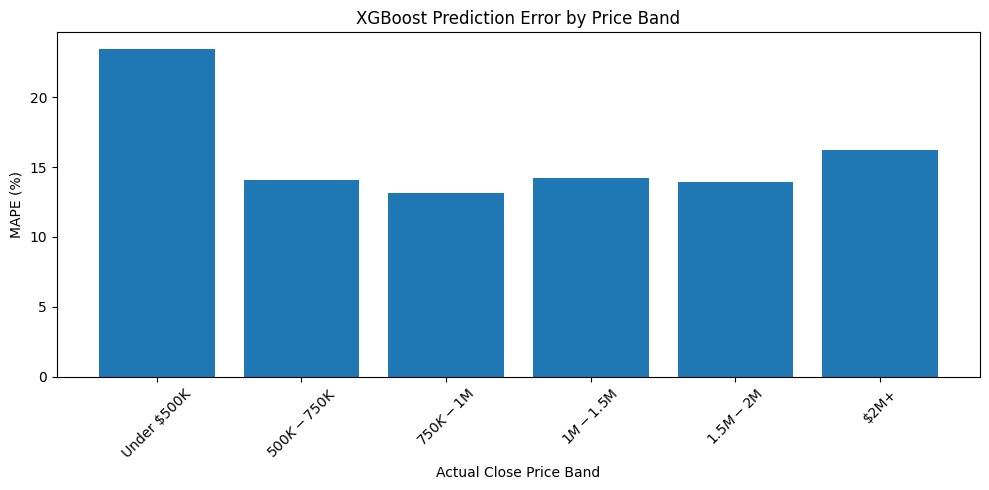

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    price_band_summary["PriceBand"].astype(str),
    price_band_summary["MAPE"]
)

plt.xlabel("Actual Close Price Band")
plt.ylabel("MAPE (%)")
plt.title("XGBoost Prediction Error by Price Band")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

```
The model performed best in the $750K–$1M segment based on MAPE.

The weakest percentage accuracy was observed in the Under $500K segment.

The $2M+ segment had the largest absolute error, with MAE around $544K.
```